# Análisis de Centralidad con PageRank

## Medidas de Centralidad y Algoritmos de Grafos

### Objetivo

Aplicar el algoritmo PageRank sobre el grafo de FraudeLink utilizando
Neo4j Graph Data Science (GDS), con el objetivo de identificar y priorizar
cuentas o entidades estructuralmente relevantes dentro de la red.

El resultado será un ranking de nodos que pueda apoyar la investigación
de posibles patrones de fraude.

## Instalacion de GDS

In [2]:
%pip install graphdatascience pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install python-dotenv

Note: you may need to restart the kernel to use updated packages.


## Importacion de librerias

In [4]:
import os 
import pandas as pd
import matplotlib.pyplot as plt

import graphdatascience as gds

c:\Users\Jimena\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Establecer conexion a Neo4j

In [5]:
import os
from dotenv import load_dotenv
from graphdatascience import GraphDataScience

load_dotenv()

NEO4J_URI = os.getenv("NEO4J_URI")
NEO4J_USERNAME = os.getenv("NEO4J_USERNAME")
NEO4J_PASSWORD = os.getenv("NEO4J_PASSWORD")

gds = GraphDataScience(
    NEO4J_URI,
    auth=(NEO4J_USERNAME, NEO4J_PASSWORD)
)

prueba = gds.run_cypher("RETURN 1 AS prueba")

print("Conexión establecida con Neo4j")
print(prueba)

Conexión establecida con Neo4j
   prueba
0       1


In [6]:
resultado = gds.run_cypher("RETURN 1 AS prueba")
resultado

,prueba
0,1


In [7]:
print("Version GDS:", gds.server_version())

Version GDS: 2026.9.0


## Verificar nodos y relaciones

### Datos de prueba

In [8]:
datos_prueba = """
CREATE (cl1:Cliente {cliente_id: 'CL001', nombre: 'Ana'})
CREATE (cl2:Cliente {cliente_id: 'CL002', nombre: 'Luis'})
CREATE (cl3:Cliente {cliente_id: 'CL003', nombre: 'Carlos'})
CREATE (cl4:Cliente {cliente_id: 'CL004', nombre: 'María'})

CREATE (c1:Cuenta {cuenta_id: 'CTA001'})
CREATE (c2:Cuenta {cuenta_id: 'CTA002'})
CREATE (c3:Cuenta {cuenta_id: 'CTA003'})
CREATE (c4:Cuenta {cuenta_id: 'CTA004'})
CREATE (c5:Cuenta {cuenta_id: 'CTA005'})

CREATE (d1:Dispositivo {dispositivo_id: 'DEV001'})
CREATE (d2:Dispositivo {dispositivo_id: 'DEV002'})

CREATE (ip1:IP {ip_address: '192.168.1.10'})
CREATE (ip2:IP {ip_address: '192.168.1.20'})

CREATE (co1:Comercio {comercio_id: 'COM001', nombre: 'Comercio A'})

// Propiedad de cuentas
CREATE (cl1)-[:POSEE]->(c1)
CREATE (cl2)-[:POSEE]->(c2)
CREATE (cl3)-[:POSEE]->(c3)
CREATE (cl4)-[:POSEE]->(c4)

// Dispositivos compartidos
CREATE (c1)-[:USA_DISPOSITIVO]->(d1)
CREATE (c2)-[:USA_DISPOSITIVO]->(d1)
CREATE (c3)-[:USA_DISPOSITIVO]->(d1)

CREATE (c4)-[:USA_DISPOSITIVO]->(d2)
CREATE (c5)-[:USA_DISPOSITIVO]->(d2)

// IP compartidas
CREATE (c1)-[:CONECTA_DESDE]->(ip1)
CREATE (c2)-[:CONECTA_DESDE]->(ip1)
CREATE (c3)-[:CONECTA_DESDE]->(ip1)

CREATE (c4)-[:CONECTA_DESDE]->(ip2)
CREATE (c5)-[:CONECTA_DESDE]->(ip2)

// Transferencias
CREATE (c1)-[:TRANSFIERE_A {monto: 500}]->(c3)
CREATE (c2)-[:TRANSFIERE_A {monto: 700}]->(c3)
CREATE (c4)-[:TRANSFIERE_A {monto: 900}]->(c3)
CREATE (c5)-[:TRANSFIERE_A {monto: 1100}]->(c3)

CREATE (c3)-[:TRANSFIERE_A {monto: 400}]->(c1)

// Pagos
CREATE (c1)-[:PAGA_EN {monto: 100}]->(co1)
CREATE (c2)-[:PAGA_EN {monto: 120}]->(co1)
CREATE (c3)-[:PAGA_EN {monto: 200}]->(co1)
"""

gds.run_cypher(datos_prueba)

print("Datos de prueba creados")

Datos de prueba creados


### Contar nodos

In [9]:
query_nodos = """
MATCH (n)
RETURN labels(n)[0] AS tipo, count(*) AS cantidad
ORDER BY cantidad DESC
"""

nodos_df = gds.run_cypher(query_nodos)
nodos_df 

,tipo,cantidad
0,Cuenta,5
1,Cliente,4
2,Dispositivo,2
3,IP,2
4,Comercio,1


### Contar relaciones

In [10]:
query_relaciones = """
MATCH ()-[r]->()
RETURN type(r) AS relacion, count(*) AS cantidad
ORDER BY cantidad DESC
"""

relaciones_df = gds.run_cypher(query_relaciones)
relaciones_df

,relacion,cantidad
0,USA_DISPOSITIVO,5
1,CONECTA_DESDE,5
2,TRANSFIERE_A,5
3,POSEE,4
4,PAGA_EN,3


### Carga y verificacion de datos dummy

In [11]:
graph_name = "fraudelink_graph"

exists = gds.graph.exists(graph_name)
exists

np.False_

In [12]:
G, metadata = gds.graph.project.native(
    "fraudelink_graph",
    ["Cliente", "Cuenta", "Dispositivo", "IP", "Comercio"],
    {
        "POSEE": {"orientation": "UNDIRECTED"},
        "USA_DISPOSITIVO": {"orientation": "UNDIRECTED"},
        "CONECTA_DESDE": {"orientation": "UNDIRECTED"},
        "TRANSFIERE_A": {"orientation": "NATURAL"},
        "PAGA_EN": {"orientation": "NATURAL"}
    }
)

print("Nodos proyectados:", G.node_count())
print("Relaciones proyectadas:", G.relationship_count())

Nodos proyectados: 14
Relaciones proyectadas: 36


## PageRank

In [13]:
pagerank_df = gds.page_rank.stream(G)

pagerank_df = pagerank_df.sort_values(by='score', ascending=False)

pagerank_df.head(10)

,nodeId,score
6,6,1.611527
4,4,1.143544
7,7,0.846743
5,5,0.824271
11,11,0.757287
9,9,0.757287
13,13,0.757287
8,8,0.566500
10,10,0.490192
12,12,0.490192


In [14]:
query_pagerank = """
CALL gds.pageRank.stream('fraudelink_graph')
YIELD nodeId, score

WITH gds.util.asNode(nodeId) AS node, score

RETURN
    labels(node)[0] AS tipo,
    coalesce(node.cliente_id, node.cuenta_id, node.dispositivo_id, node.ip_address, node.comercio_id) AS id,
    score AS pagerank

ORDER BY pagerank DESC
LIMIT 20
"""

pagerank_general = gds.run_cypher(query_pagerank)
pagerank_general

,tipo,id,pagerank
0,Cuenta,CTA003,1.611527
1,Cuenta,CTA001,1.143544
2,Cuenta,CTA004,0.846743
3,Cuenta,CTA002,0.824271
4,Dispositivo,DEV001,0.757287
5,IP,192.168.1.10,0.757287
6,Comercio,COM001,0.757287
7,Cuenta,CTA005,0.566500
8,Dispositivo,DEV002,0.490192
9,IP,192.168.1.20,0.490192


In [15]:
query_cuentas = """
CALL gds.pageRank.stream('fraudelink_graph')
YIELD nodeId, score

WITH gds.util.asNode(nodeId) AS node, score

WHERE node:Cuenta

RETURN
    node.cuenta_id AS cuenta_id,
    score AS pagerank

ORDER BY pagerank DESC
LIMIT 10
"""

ranking_cuentas = gds.run_cypher(query_cuentas)
ranking_cuentas

,cuenta_id,pagerank
0,CTA003,1.611527
1,CTA001,1.143544
2,CTA004,0.846743
3,CTA002,0.824271
4,CTA005,0.566500


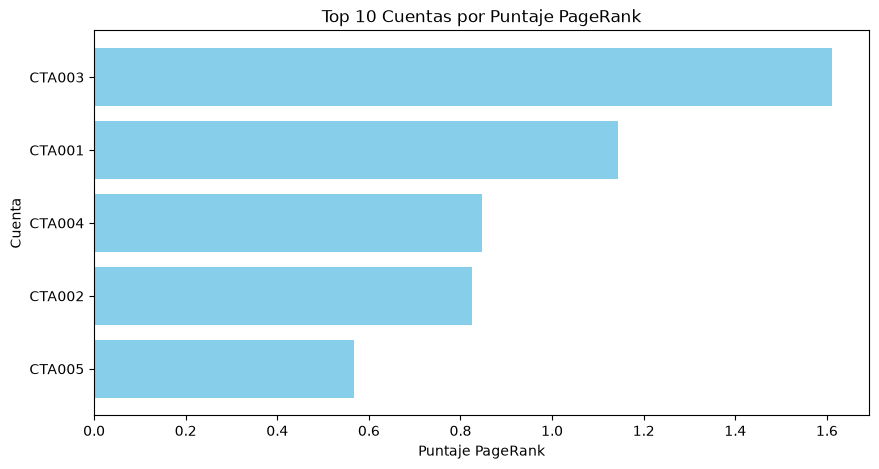

In [16]:
import matplotlib.pyplot as plt

top10 = ranking_cuentas.head(10)

plt.figure(figsize=(10, 5))

plt.barh(top10['cuenta_id'], top10['pagerank'], color='skyblue')

plt.xlabel('Puntaje PageRank')
plt.ylabel('Cuenta')
plt.title('Top 10 Cuentas por Puntaje PageRank')

plt.gca().invert_yaxis()  # Invertir el eje y para mostrar la cuenta con mayor PageRank en la parte superior

plt.show()

## Análisis matemático de PageRank

PageRank asigna a cada nodo una puntuación de importancia según las conexiones que reciba cada nodo y la importancia que generan esas mismas coenxiones.

A continuación se muestra la fórmula simplificada:

$$
PR(v) = (1-d) + d \sum_{u \in In(v)} \frac{PR(u)}{L(u)}
$$

donde:

- \(PR(v)\) es el puntaje PageRank del nodo \(v\).
- \(d\) es el factor de amortiguamiento el cual indica cuánto peso se da a las conexiones del grafo frente a una probabilidad base de salto aleatorio. En PageRank suele usarse \(d = 0.85\).
- \(In(v)\) es el conjunto de nodos que tienen una relación dirigida hacia \(v\).
- \(PR(u)\) representa la importancia del nodo origen.
- \(L(u)\) es la cantidad de relaciones salientes del nodo \(u\).

El cálculo se realiza de forma iterativa. En cada iteración, cada nodo distribuye parte de su importancia entre los nodos a los que apunta.
Las puntuaciones se actualizan hasta que los cambios entre iteraciones son suficientemente pequeños.

* Neo4j usa por defecto un factor de amortiguamiento de 0.85, y PageRank considera tanto la cantidad de relaciones entrantes como la importancia de los nodos desde donde vienen esas relaciones.

### Ejemplo del caso

Sea por ejemplo que se tienen las siguientes cuentas (nodos) que apuntan a otras:

```text
CTA001 → CTA003
CTA002 → CTA003
CTA004 → CTA003
CTA005 → CTA003
```

Entonces `CTA003` recibe una importancia de 4 nodos.

No obstante, PageRank no se basa en que tenga 4 conexiones y que gane automaticamente, sino cada nodo que apunta a `CTA003` le transfiere una parte de su propio PageRank. 


Entonces sea por ejemplo que `CTA001` tiene un PageRank alto y pocas relaciones salientes, una mayor parte de su importancia llega a `CTA003`.

Conceptualmente hablando:

$$
\text{Aporte de CTA001} =
\frac{PR(CTA001)}{L(CTA001)}
$$

Por ejemplo, si hipotéticamente:

$$
PR(CTA001) = 1.2
$$

y la cuenta tiene 2 relaciones salientes:

$$
\frac{1.2}{2} = 0.6
$$

Entonces, CTA001 aporta aproximadamente **0.6** antes de aplicar el factor de amortiguamiento.

En cambio, si otra cuenta tiene:

$$
PR(CTA002) = 1.2
$$

pero posee 12 relaciones salientes:

$$
\frac{1.2}{12} = 0.1
$$

su aporte individual es mucho menor.

Por eso, **no todas las conexiones tienen el mismo efecto dentro de PageRank**.



## Justificación en la investigación de fraude

PageRank es útil en FraudeLink porque permite identificar nodos que ocupan
una posición estructuralmente importante dentro de la red.

Una cuenta puede obtener un PageRank elevado cuando recibe conexiones desde
varios nodos que, a su vez, también tienen importancia dentro del grafo.

Esto permite priorizar cuentas que podrían funcionar como puntos de
concentración, intermediarios relevantes o destinos recurrentes dentro de
una red de relaciones.

Por ejemplo, si varias cuentas estructuralmente relevantes transfieren hacia
una misma cuenta, esa cuenta puede acumular un PageRank mayor y aparecer en
las primeras posiciones del ranking.

Esto no demuestra fraude por sí solo, pero permite reducir el espacio de
búsqueda y priorizar qué cuentas deberían analizarse con mayor detalle.


**En nuestra implementación, el score representa relevancia estructural dentro de la red completa de FraudeLink. Por eso una cuenta puede ganar importancia no solo por transferencias, sino también por sus conexiones con dispositivos, IP, clientes y comercios.**